In [1]:
%run shared_imports.py

In [2]:
engine = make_engine("settings.toml")
session = Session(engine)

In [135]:
query = select(Feedback.json, Feedback.datetime).filter(
        Feedback.key_name == 'votes',
        Feedback.datetime >= datetime(2024, 8, 1))
df = pd.read_sql_query(query, session.connection())

In [136]:
def map_votes(row):
    result = dict()
    for vote, counts in row['data'].items():
        if vote == 'map':
            for map_name, count in counts.items():
                result[map_name] = count
    return result

In [137]:
normalized = df.join(pd.json_normalize(df.json.map(map_votes))).drop(['json'], axis=1)

In [140]:
summed = normalized.resample('D', on='datetime')[list(shipnames)].sum()

In [139]:
shipnames = ['NSS Cyberiad (Cyberiad)', 'NSS Farragus (CereStation)',
       'NSS Cerebron (MetaStation)', 'NSS Kerberos (Delta)',
       'NSS Diagoras (EmeraldStation)']

In [141]:
normalized.columns[1:]

Index(['NSS Cerebron (MetaStation)', 'NSS Farragus (CereStation)',
       'NSS Kerberos (Delta)', 'NSS Cyberiad (Cyberiad)',
       'NSS Diagoras (EmeraldStation)'],
      dtype='object')

In [142]:
cols = [str(x) for x in normalized.columns[1:]]
summed[cols] = summed[cols].div(summed[cols].sum(axis=1), axis=0).multiply(100)

In [146]:
dropped_random_days = summed[summed['NSS Cyberiad (Cyberiad)'].notna()]

In [159]:
dropped_random_days

,NSS Cyberiad (Cyberiad),NSS Farragus (CereStation),NSS Cerebron (MetaStation),NSS Kerberos (Delta),NSS Diagoras (EmeraldStation)
datetime,,,,,
2024-08-02,65.753425,15.525114,9.589041,9.132420,0.000000
2024-08-03,37.748344,21.192053,25.165563,15.894040,0.000000
2024-08-04,30.769231,19.711538,26.442308,23.076923,0.000000
2024-08-05,66.860465,17.441860,8.720930,6.976744,0.000000
2024-08-07,65.354331,17.322835,7.086614,10.236220,0.000000
2024-08-09,59.615385,14.423077,12.980769,12.980769,0.000000
2024-08-10,35.714286,20.833333,19.047619,24.404762,0.000000
2024-08-11,39.325843,14.606742,22.471910,23.595506,0.000000
2024-08-12,65.517241,15.862069,5.517241,13.103448,0.000000


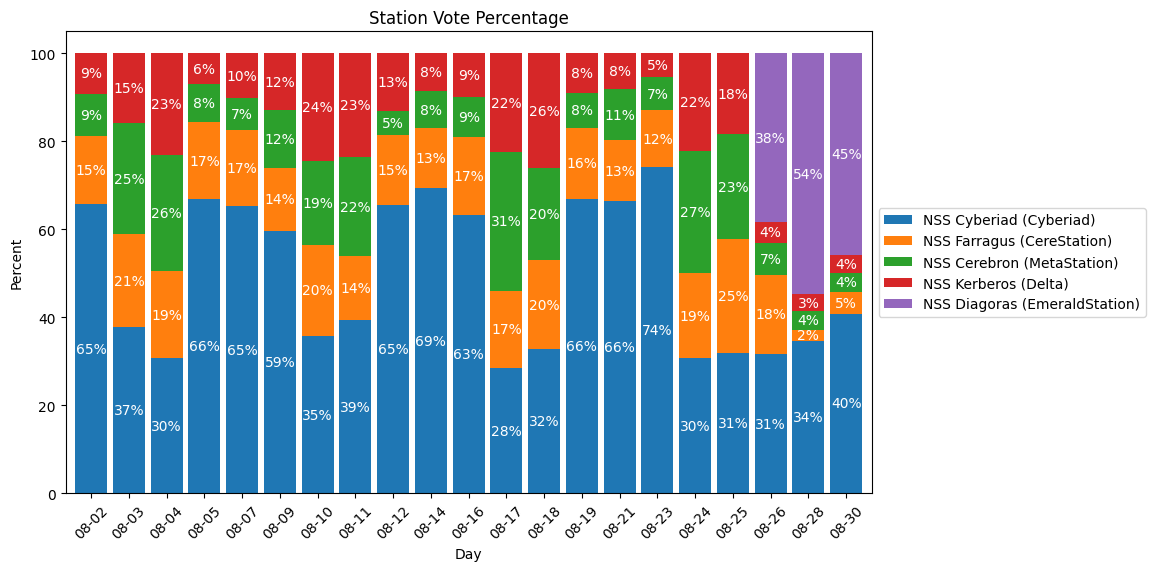

In [158]:
fig, ax = plt.subplots()
fig.set_size_inches(13, 6)

plot = dropped_random_days.plot(kind='bar', stacked=True, ax=ax, width=0.85)
for c in ax.containers:
    labels = [f"{int(v.get_height())}%" if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white')
ax.set_xticklabels([x.strftime("%m-%d") for x in dropped_random_days.index], rotation=45)
plt.title("Station Vote Percentage")
ax.set_xlabel('Day')
ax.set_ylabel('Percent')
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('emerald_intro_week.png')